# **EKSTRAK SUMBER DATA KE-1 PDF IPM SUMBER BPS**

In [ ]:
!pip install pdfplumber
import pdfplumber
import pandas as pd
from google.colab import files

In [ ]:
from IPython.display import clear_output, display
uploaded = files.upload()

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    pdf_path = f"/content/{uploaded_filename}"
else:
    raise FileNotFoundError("Tidak ada file yang diunggah.")

page_index = 363
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[page_index]
    tables = page.extract_tables()

if len(tables) == 0:
    raise ValueError("Tabel tidak ditemukan pada halaman 364.")

table = tables[0]
df = pd.DataFrame(table)

df.columns = df.iloc[0]
df = df[1:]
df = df.rename(columns=lambda x: str(x).strip())

col_prov = [c for c in df.columns if "Prov" in str(c) or "PROV" in str(c)][0]
col_2021 = [c for c in df.columns if "2021" in str(c)][0]
col_2022 = [c for c in df.columns if "2022" in str(c)][0]
col_2023 = [c for c in df.columns if "2023" in str(c)][0]

df_final = df[[col_prov, col_2021, col_2022, col_2023]]
df_final.columns = ["Provinsi", "IPM_2021", "IPM_2022", "IPM_2023"]

output_csv = "/content/ipm_sudah_ekstrak.csv"
df_final.to_csv(output_csv, index=False, encoding="utf-8-sig")

clear_output(wait=True)
display(df_final.head())

,Provinsi,IPM_2021,IPM_2022,IPM_2023
1,(1),(2),(3),(4)
2,Aceh,"73,48","74,11","74,70"
3,Sumatera Utara,"73,84","74,51","75,13"
4,Sumatera Barat,"74,56","75,16","75,64"
5,Riau,"73,89","74,45","74,95"


# **HAPUS KARAKTER ANEH, HAPUS PROVINSI YANG TIDAK DIPERLUKAN**

In [ ]:
import re
df = pd.read_csv("/content/ipm_sudah_ekstrak.csv")
def clean_province(name):
    name = str(name)
    m = re.search(r"[A-Z]", name)
    if m:
        name = name[m.start():]
    name = re.sub(r"[^A-Za-z\s\.]", "", name)
    name = re.sub(r"\s+", " ", name)
    return name.strip()

df["Provinsi"] = df["Provinsi"].apply(clean_province)
df["Provinsi"] = df["Provinsi"].replace(
    {"D.I. Yogyakarta": "DI YOGYAKARTA"}
)
hapus_list = [
    "indonesia",
    "papua tengah",
    "papua selatan",
    "papua pegunungan",
    "papua barat daya"
]

df = df[~df["Provinsi"].str.lower().isin(hapus_list)]
def is_garbage_row(x):
    x = str(x).strip()
    if x == "":
        return True
    if re.match(r"^\(\d+\)$", x):
        return True
    if re.match(r"^\d+(\.\d+)?$", x):
        return True
    return False

df = df[~df["Provinsi"].apply(is_garbage_row)]
def clean_number(x):
    x = str(x)
    x = re.sub(r"[^0-9,]", "", x)
    x = x.replace(",", ".")
    return float(x) if x else None

for col in ["IPM_2021", "IPM_2022", "IPM_2023"]:
    df[col] = df[col].apply(clean_number)
df = df.reset_index(drop=True)
df.to_csv("/content/ipm clean.csv", index=False, encoding="utf-8-sig")
df


# **LOAD SUMBER DATA KE-2 YAITU TINGKAT PENGANGGURAN TERBUKA DARI OPENDATA.JABAR**

In [ ]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

df_filtered_years = df[df['tahun'].isin([2021, 2022, 2023])].copy()

df_pivot = df_filtered_years.pivot_table(
    index='nama_provinsi',
    columns='tahun',
    values='indeks_tpt'
).reset_index()

df_pivot.columns.name = None

df_out = df_pivot.rename(columns={
    'nama_provinsi': 'Provinsi',
    2021: 'PRESENTASE_TINGKAT_PENGANGGURAN_2021',
    2022: 'PRESENTASE_TINGKAT_PENGANGGURAN_2022',
    2023: 'PRESENTASE_TINGKAT_PENGANGGURAN_2023'
})

df_out = df_out[['Provinsi', 'PRESENTASE_TINGKAT_PENGANGGURAN_2021', 'PRESENTASE_TINGKAT_PENGANGGURAN_2022', 'PRESENTASE_TINGKAT_PENGANGGURAN_2023']]

df_out.to_csv("/content/tingkat pengangguran clean.csv", index=False, encoding="utf-8-sig")

clear_output()
display(df_out.head())

,Provinsi,PRESENTASE_TINGKAT_PENGANGGURAN_2021,PRESENTASE_TINGKAT_PENGANGGURAN_2022,PRESENTASE_TINGKAT_PENGANGGURAN_2023
0,ACEH,6.30,6.17,6.03
1,BALI,5.37,4.80,2.69
2,BANTEN,8.98,8.09,7.52
3,BENGKULU,3.65,3.59,3.42
4,DI YOGYAKARTA,4.56,4.06,3.69


# **LOAD SUMBER KE-3 YAITU JUMLAH TINDAK PIDANA BERUPA 3 CSV SUMBER BPS LALU MERGE**

In [ ]:
from google.colab import files
from IPython.display import clear_output, display

uploaded = files.upload()
if len(uploaded) != 3:
    raise ValueError("Harus upload tepat 3 file!")

def detect_year_from_fname(fname):
    m = re.search(r'20(21|22|23)', fname)
    if m:
        return int(m.group(0))
    try:
        df_tmp = pd.read_csv(io.BytesIO(uploaded[fname]), nrows=1)
        for col in df_tmp.columns:
            m2 = re.search(r'20(21|22|23)', str(col))
            if m2:
                return int(m2.group(0))
    except:
        pass
    return None

year_to_file = {}
for fname in uploaded.keys():
    yr = detect_year_from_fname(fname)
    if yr is None:
        raise ValueError(f"Tidak bisa mendeteksi tahun dari file: {fname}. Pastikan nama file mengandung 2021/2022/2023.")
    if yr in year_to_file:
        raise ValueError(f"Duplikasi tahun {yr} pada file: {fname} dan {year_to_file[yr]}.")
    year_to_file[yr] = fname

missing_years = {2021, 2022, 2023} - set(year_to_file.keys())
if missing_years:
    raise ValueError(f"File untuk tahun berikut tidak ditemukan: {sorted(list(missing_years))}")

file_2021 = year_to_file[2021]
file_2022 = year_to_file[2022]
file_2023 = year_to_file[2023]

def load_and_clean(file_key, year_label):
    df = pd.read_csv(io.BytesIO(uploaded[file_key]))
    df = df.dropna(how="all")
    prov_col = df.columns[0]
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    val_col = numeric_cols[-1] if numeric_cols else df.columns[-1]

    df = df.rename(columns={prov_col: "PROVINSI", val_col: year_label})
    df = df[["PROVINSI", year_label]]
    df = df[df["PROVINSI"].astype(str).str.len() > 1]
    df = df[df["PROVINSI"].astype(str).str.upper() != "INDONESIA"]

    # Normalisasi nama provinsi
    df["PROVINSI"] = df["PROVINSI"].astype(str).str.upper().str.strip()
    df["PROVINSI"] = df["PROVINSI"].replace({
        "METRO JAYA": "DKI JAKARTA",
        "KEP. BANGKA BELITUNG": "KEPULAUAN BANGKA BELITUNG",
        "KEP. RIAU": "KEPULAUAN RIAU"
    })

    df[year_label] = pd.to_numeric(df[year_label], errors="coerce")
    df = df.dropna(subset=[year_label])

    df.reset_index(drop=True, inplace=True)
    return df

df21 = load_and_clean(file_2021, "JUMLAH_TINDAK_PIDANA_2021")
df22 = load_and_clean(file_2022, "JUMLAH_TINDAK_PIDANA_2022")
df23 = load_and_clean(file_2023, "JUMLAH_TINDAK_PIDANA_2023")

merged = df21.merge(df22, on="PROVINSI", how="left").merge(df23, on="PROVINSI", how="left")

merged.to_csv("tindak pidana clean.csv", index=False)

clear_output()
display(merged.head(10))


# **LOAD SUMBER KE-4 YAITU PENDUDUK MISKIN CSV SUMBER KAGGLE**

In [ ]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

df_filtered = df[df['tahun'].isin([2021, 2022, 2023])]

df_pivot = df_filtered.pivot_table(
    index='nama_provinsi',
    columns='tahun',
    values='persentase_penduduk_miskin'
).reset_index()

hapus_list = [
    "PAPUA BARAT DAYA",
    "PAPUA PEGUNUNGAN",
    "PAPUA SELATAN",
    "PAPUA TENGAH"
]

df_pivot = df_pivot[~df_pivot['nama_provinsi'].isin(hapus_list)]

df_pivot.columns = [
    "PROVINSI",
    "PRESENTASE_PENDUDUK_MISKIN_2021",
    "PRESENTASE_PENDUDUK_MISKIN_2022",
    "PRESENTASE_PENDUDUK_MISKIN_2023"
]

df_pivot.to_csv("penduduk miskin clean.csv", index=False)

clear_output()
display(df_pivot.head())

,PROVINSI,PRESENTASE_PENDUDUK_MISKIN_2021,PRESENTASE_PENDUDUK_MISKIN_2022,PRESENTASE_PENDUDUK_MISKIN_2023
0,ACEH,15.33,14.64,14.45
1,BALI,4.53,4.57,4.25
2,BANTEN,6.66,6.16,6.17
3,BENGKULU,15.22,14.62,14.04
4,DI YOGYAKARTA,12.80,11.34,11.04


# **MERGE SEMUA FILE YG BERNAMA CLEAN**

In [ ]:
from openpyxl.styles import Font, PatternFill, Border, Side
from openpyxl.utils import get_column_letter
df_pengangguran = pd.read_csv("/content/tingkat pengangguran clean.csv")
df_pidana = pd.read_csv("/content/tindak pidana clean.csv")
df_ipm = pd.read_csv("/content/ipm clean.csv")
df_miskin = pd.read_csv("/content/penduduk miskin clean.csv")
print("Semua file CSV berhasil dimuat dari direktori /content/.")
df_pengangguran.rename(columns={'Provinsi': 'PROVINSI'}, inplace=True)
df_pengangguran['PROVINSI'] = df_pengangguran['PROVINSI'].str.upper()
df_ipm.rename(columns={'Provinsi': 'PROVINSI'}, inplace=True)
df_ipm['PROVINSI'] = df_ipm['PROVINSI'].str.upper()
df_miskin.rename(columns={'PROVINSI': 'PROVINSI'}, inplace=True)
df_miskin['PROVINSI'] = df_miskin['PROVINSI'].str.upper()
df_merge = df_pengangguran.merge(df_pidana, on="PROVINSI", how="left")
df_merge = df_merge.merge(df_ipm, on="PROVINSI", how="left")
df_merge = df_merge.merge(df_miskin, on="PROVINSI", how="left")
#XLSX DENGAN STYLE
output_name = "gabungan sudah fix.xlsx"
with pd.ExcelWriter(output_name, engine="openpyxl") as writer:
    df_merge.to_excel(writer, sheet_name="DATA", index=False)
    ws = writer.book["DATA"]
    header_fill = PatternFill(start_color="FFC000", end_color="FFC000", fill_type="solid")
    header_font = Font(bold=True, color="000000")

    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
    fill1 = PatternFill(start_color="FFF2CC", end_color="FFF2CC", fill_type="solid")
    fill2 = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")
    thin = Side(border_style="thin", color="000000")
    border = Border(top=thin, left=thin, right=thin, bottom=thin)

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
        fill = fill1 if row[0].row % 2 == 0 else fill2
        for cell in row:
            cell.fill = fill
            cell.border = border
    for col in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws.column_dimensions[col_letter].width = max_length + 2

print("\nFILE XLSX BERHASIL DIBUAT")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

df_merge.head()


Semua file CSV berhasil dimuat dari direktori /content/.

FILE XLSX BERHASIL DIBUAT


,PROVINSI,PRESENTASE_TINGKAT_PENGANGGURAN_2021,PRESENTASE_TINGKAT_PENGANGGURAN_2022,PRESENTASE_TINGKAT_PENGANGGURAN_2023,JUMLAH_TINDAK_PIDANA_2021,JUMLAH_TINDAK_PIDANA_2022,JUMLAH_TINDAK_PIDANA_2023,IPM_2021,IPM_2022,IPM_2023,PRESENTASE_PENDUDUK_MISKIN_2021,PRESENTASE_PENDUDUK_MISKIN_2022,PRESENTASE_PENDUDUK_MISKIN_2023
0,ACEH,6.30,6.17,6.03,6651.0,10137.0,12420.0,73.48,74.11,74.70,15.33,14.64,14.45
1,BALI,5.37,4.80,2.69,2404.0,6304.0,11916.0,76.69,77.40,78.01,4.53,4.57,4.25
2,BANTEN,8.98,8.09,7.52,3434.0,5038.0,7392.0,74.68,75.25,75.77,6.66,6.16,6.17
3,BENGKULU,3.65,3.59,3.42,3493.0,3613.0,5579.0,73.16,73.68,74.30,15.22,14.62,14.04
4,DI YOGYAKARTA,4.56,4.06,3.69,4774.0,10591.0,12061.0,80.22,80.65,81.09,12.80,11.34,11.04


# **VISUALISASI**

File berhasil dimuat.

Nama Kolom Standar: ['PROVINSI', 'PRESENTASE_TINGKAT_PENGANGGURAN_2021', 'PRESENTASE_TINGKAT_PENGANGGURAN_2022', 'PRESENTASE_TINGKAT_PENGANGGURAN_2023', 'JUMLAH_TINDAK_PIDANA_2021', 'JUMLAH_TINDAK_PIDANA_2022', 'JUMLAH_TINDAK_PIDANA_2023', 'IPM_2021', 'IPM_2022', 'IPM_2023', 'PRESENTASE_PENDUDUK_MISKIN_2021', 'PRESENTASE_PENDUDUK_MISKIN_2022', 'PRESENTASE_PENDUDUK_MISKIN_2023']

[KONFIGURASI VARIABEL]
Variabel Dependen (Y - Akibat): JUMLAH_TINDAK_PIDANA
Variabel Independen (X - Penyebab): ['IPM', 'PRESENTASE_PENDUDUK_MISKIN', 'PRESENTASE_TINGKAT_PENGANGGURAN']

==================== DATA INFO ====================
Jumlah Baris: 34
Jumlah Kolom: 13

Tipe Data per Kolom:
PROVINSI                                 object
PRESENTASE_TINGKAT_PENGANGGURAN_2021    float64
PRESENTASE_TINGKAT_PENGANGGURAN_2022    float64
PRESENTASE_TINGKAT_PENGANGGURAN_2023    float64
JUMLAH_TINDAK_PIDANA_2021                 int64
JUMLAH_TINDAK_PIDANA_2022                 int64
JUMLAH_TINDAK

,PROVINSI,PRESENTASE_TINGKAT_PENGANGGURAN_2021,PRESENTASE_TINGKAT_PENGANGGURAN_2022,PRESENTASE_TINGKAT_PENGANGGURAN_2023,JUMLAH_TINDAK_PIDANA_2021,JUMLAH_TINDAK_PIDANA_2022,JUMLAH_TINDAK_PIDANA_2023,IPM_2021,IPM_2022,IPM_2023,PRESENTASE_PENDUDUK_MISKIN_2021,PRESENTASE_PENDUDUK_MISKIN_2022,PRESENTASE_PENDUDUK_MISKIN_2023
0,ACEH,6.30,6.17,6.03,6651,10137,12420,73.48,74.11,74.70,15.33,14.64,14.45
1,BALI,5.37,4.80,2.69,2404,6304,11916,76.69,77.40,78.01,4.53,4.57,4.25
2,BANTEN,8.98,8.09,7.52,3434,5038,7392,74.68,75.25,75.77,6.66,6.16,6.17
3,BENGKULU,3.65,3.59,3.42,3493,3613,5579,73.16,73.68,74.30,15.22,14.62,14.04
4,DI YOGYAKARTA,4.56,4.06,3.69,4774,10591,12061,80.22,80.65,81.09,12.80,11.34,11.04



Statistik Deskriptif


,PROVINSI,PRESENTASE_TINGKAT_PENGANGGURAN_2021,PRESENTASE_TINGKAT_PENGANGGURAN_2022,PRESENTASE_TINGKAT_PENGANGGURAN_2023,JUMLAH_TINDAK_PIDANA_2021,JUMLAH_TINDAK_PIDANA_2022,JUMLAH_TINDAK_PIDANA_2023,IPM_2021,IPM_2022,IPM_2023,PRESENTASE_PENDUDUK_MISKIN_2021,PRESENTASE_PENDUDUK_MISKIN_2022,PRESENTASE_PENDUDUK_MISKIN_2023
count,34,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
unique,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ACEH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,5.492059,4.966176,4.613824,7043.558824,10967.558824,17205.617647,72.531176,73.415588,74.052353,10.762353,10.243235,10.089118
std,NaN,1.818745,1.600225,1.419065,7702.057188,12698.213733,20753.986055,3.835488,3.320884,3.291068,5.402680,5.248208,5.183509
min,NaN,3.010000,2.340000,2.270000,971.000000,1220.000000,1701.000000,61.400000,66.030000,66.840000,4.530000,4.450000,4.250000
25%,NaN,4.447500,4.000000,3.487500,2556.750000,3666.750000,5691.250000,70.957500,71.852500,72.547500,6.717500,6.257500,6.240000
50%,NaN,5.060000,4.685000,4.320000,4841.500000,5406.000000,8247.000000,72.885000,73.335000,73.910000,8.895000,8.525000,8.425000
75%,NaN,6.322500,6.047500,5.762500,7289.250000,10914.250000,15399.000000,73.877500,74.495000,75.017500,12.960000,12.222500,12.252500



Membuat Boxplot (Deteksi Outliers)...


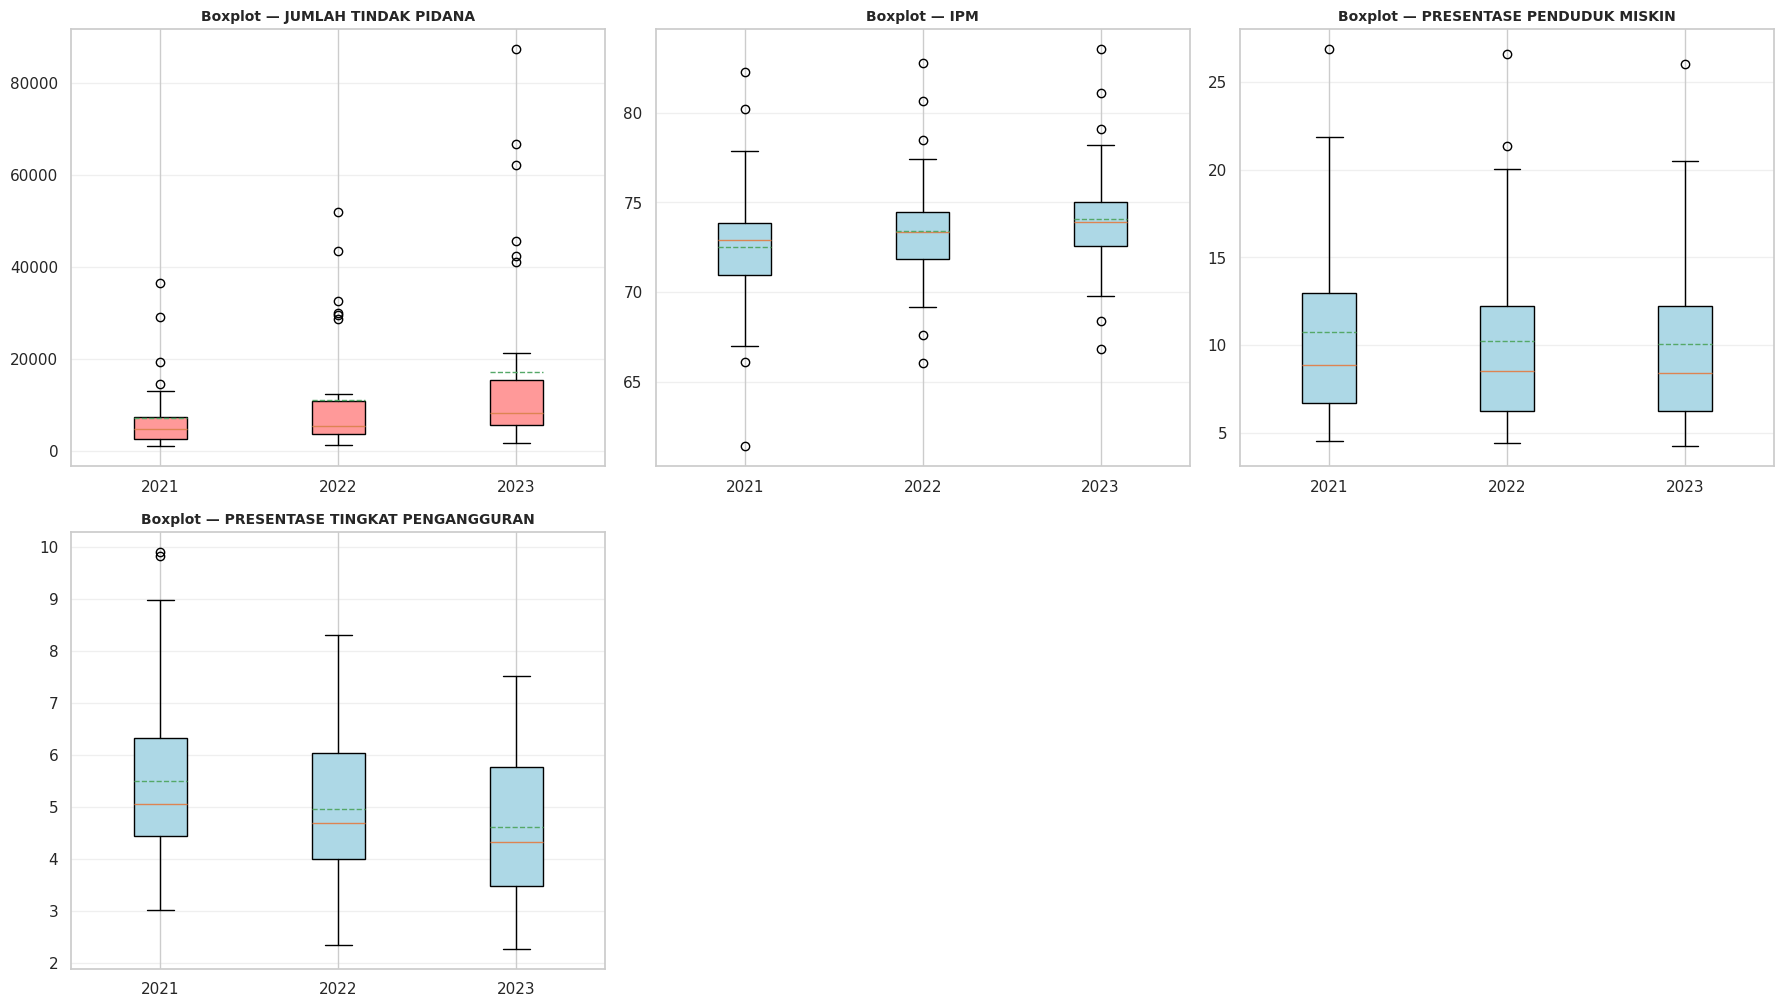


Membuat Distribution Plot...


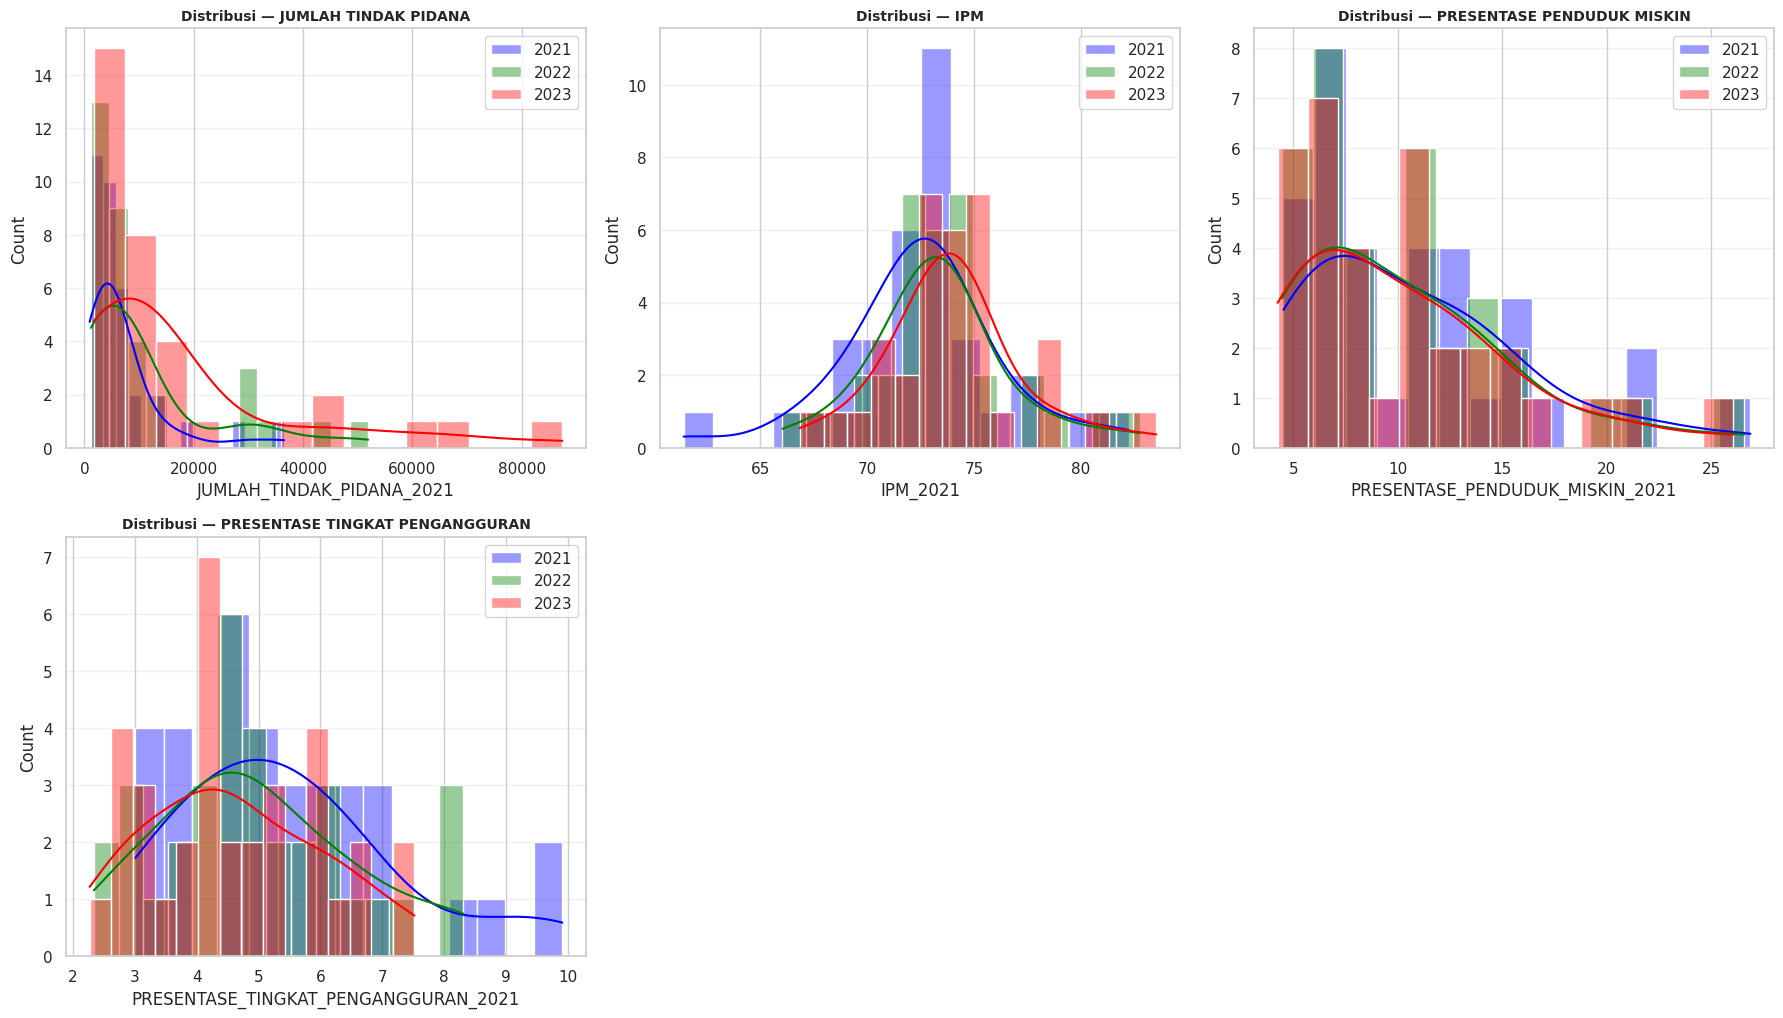


Membuat Bar Chart...


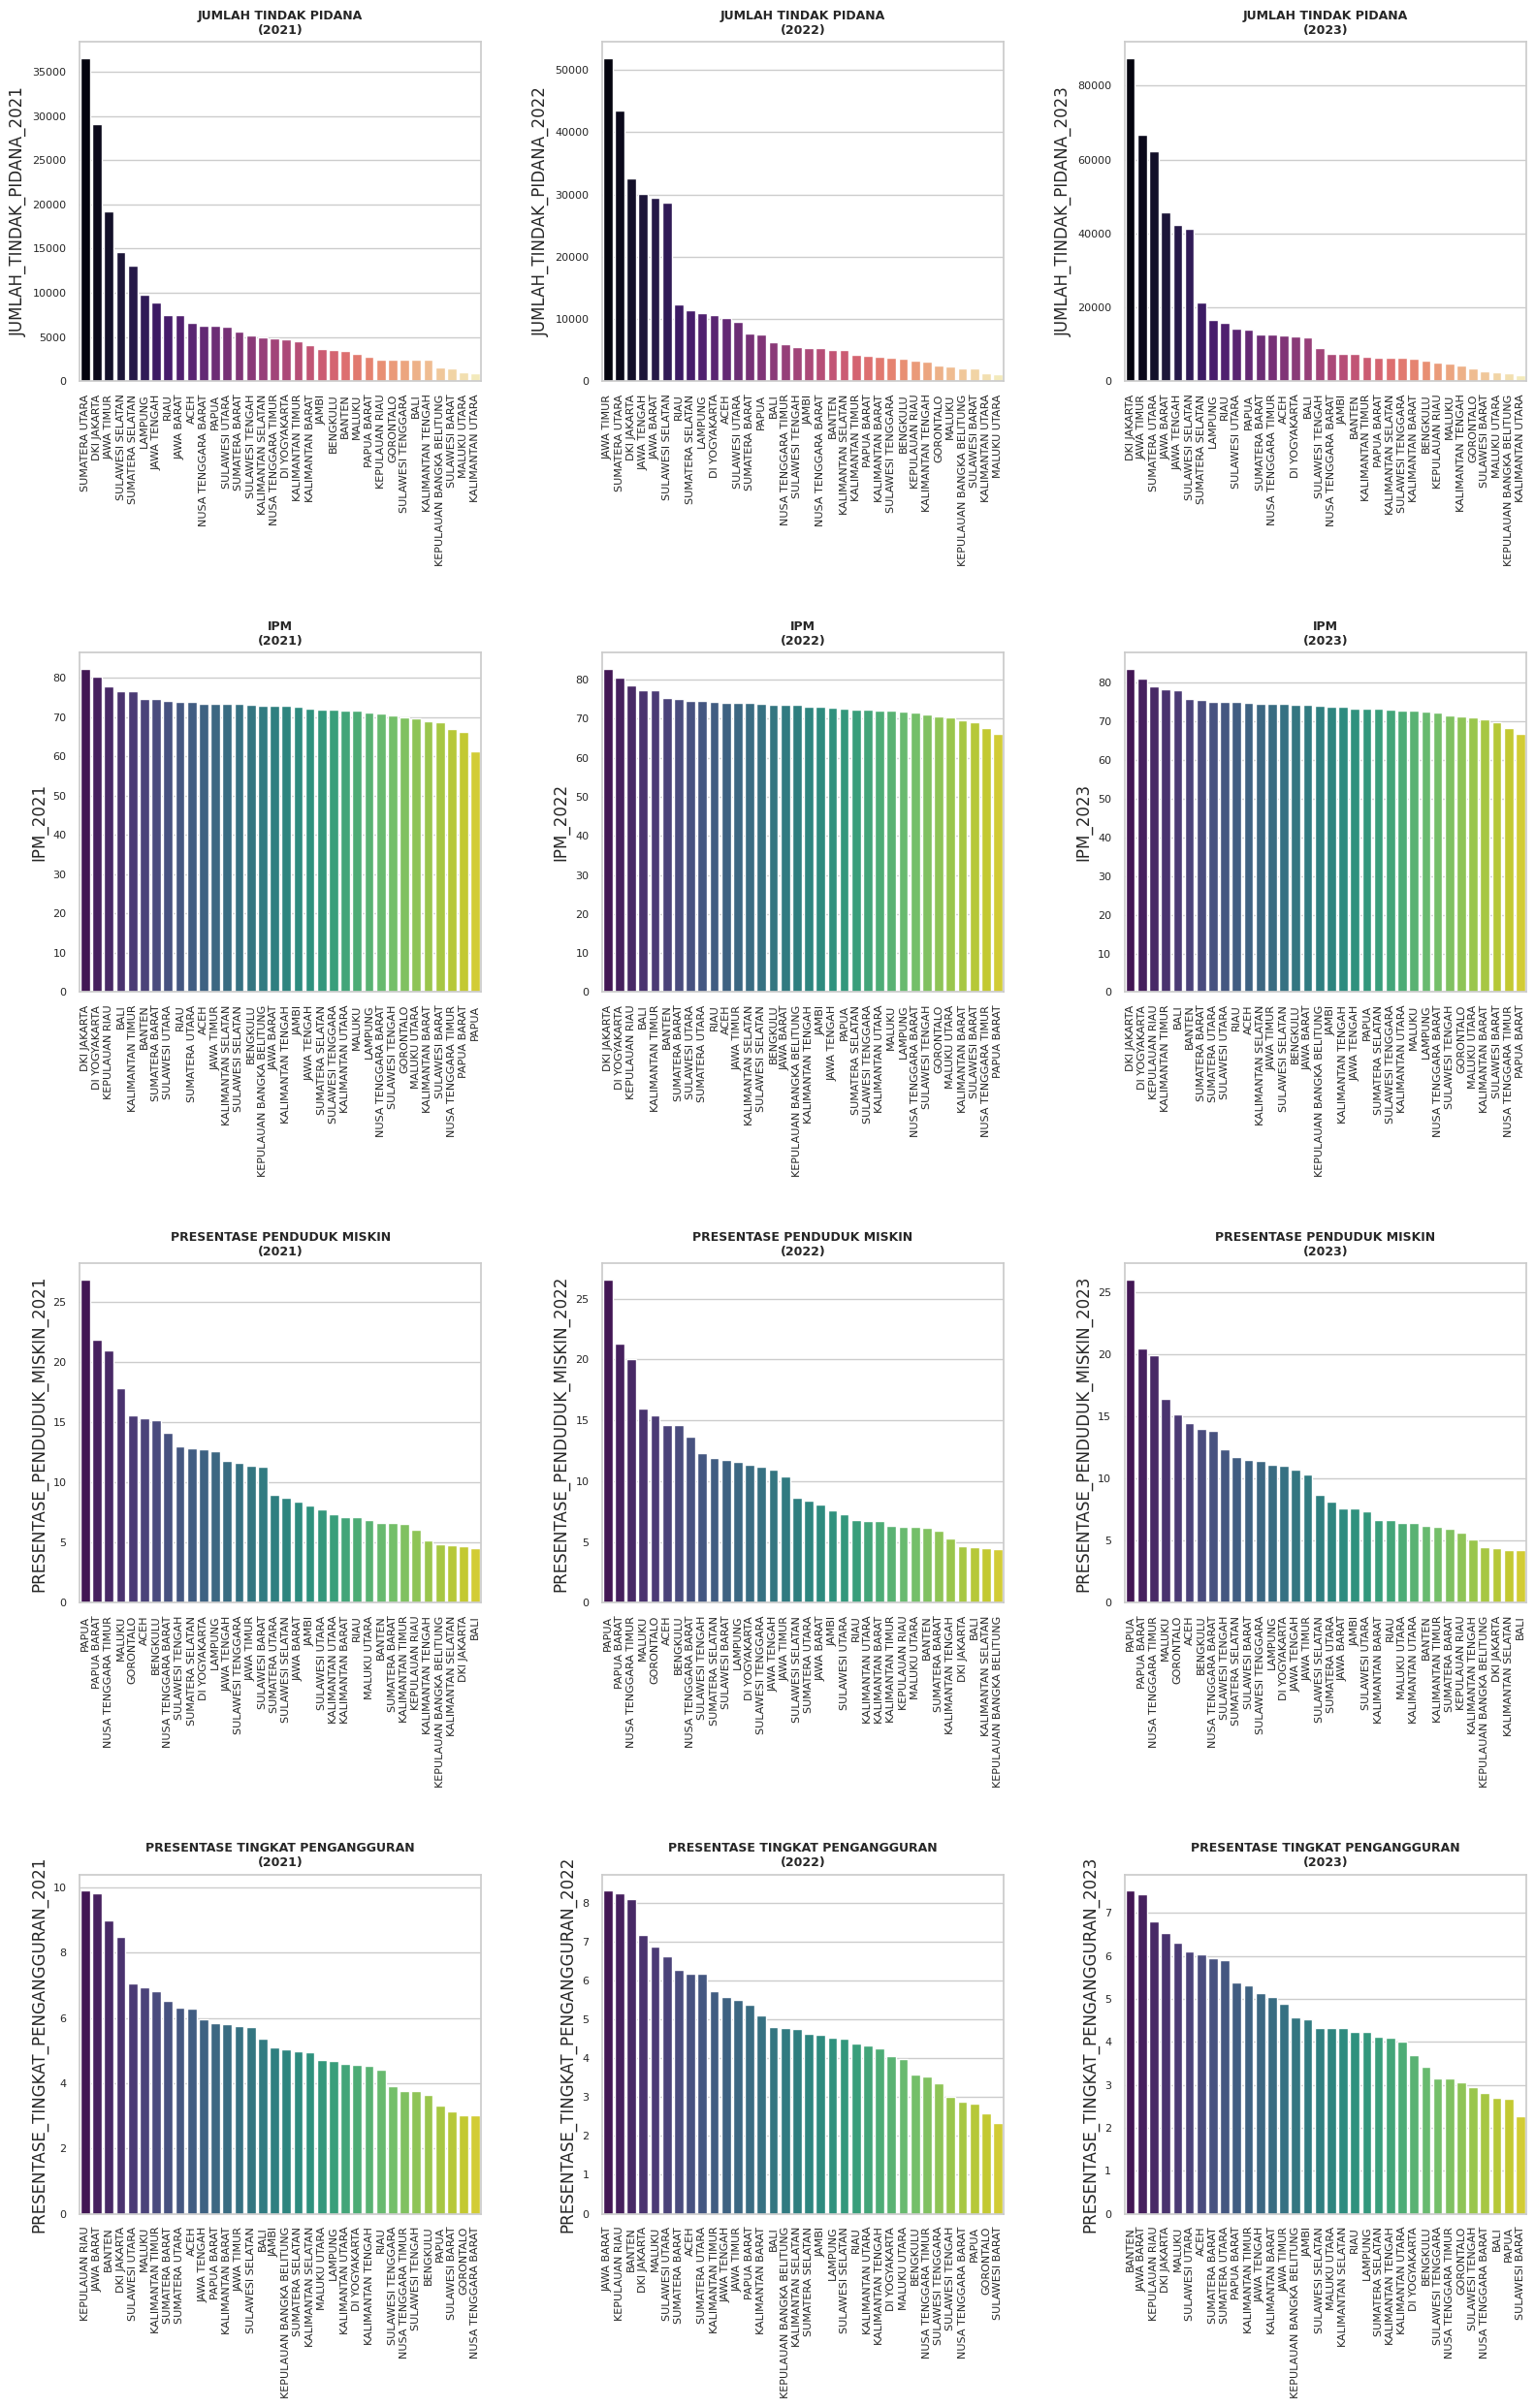


Membuat Time Series (Logika Normalisasi Manual 0-1)...


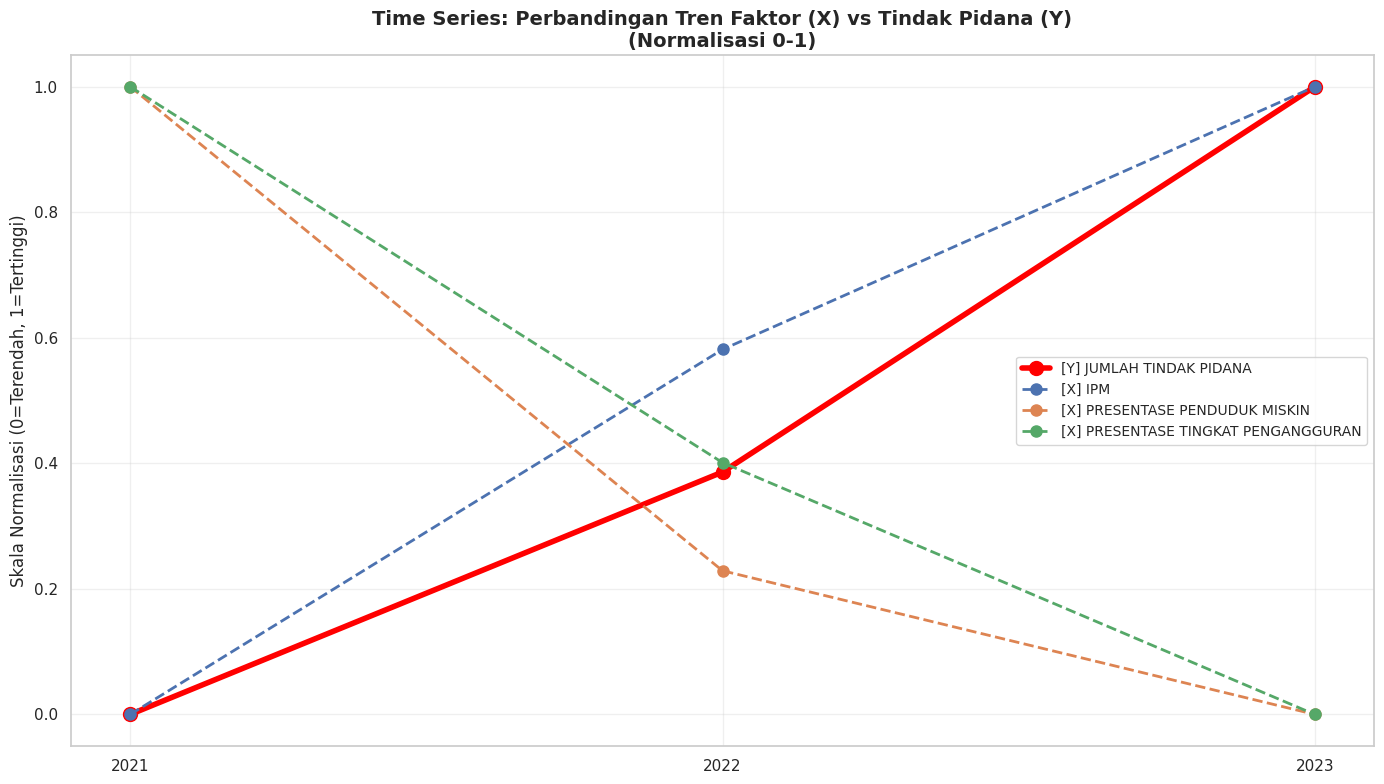


Membuat Scatter Plot: Analisis Pengaruh Faktor (X) terhadap Tindak Pidana (Y)...


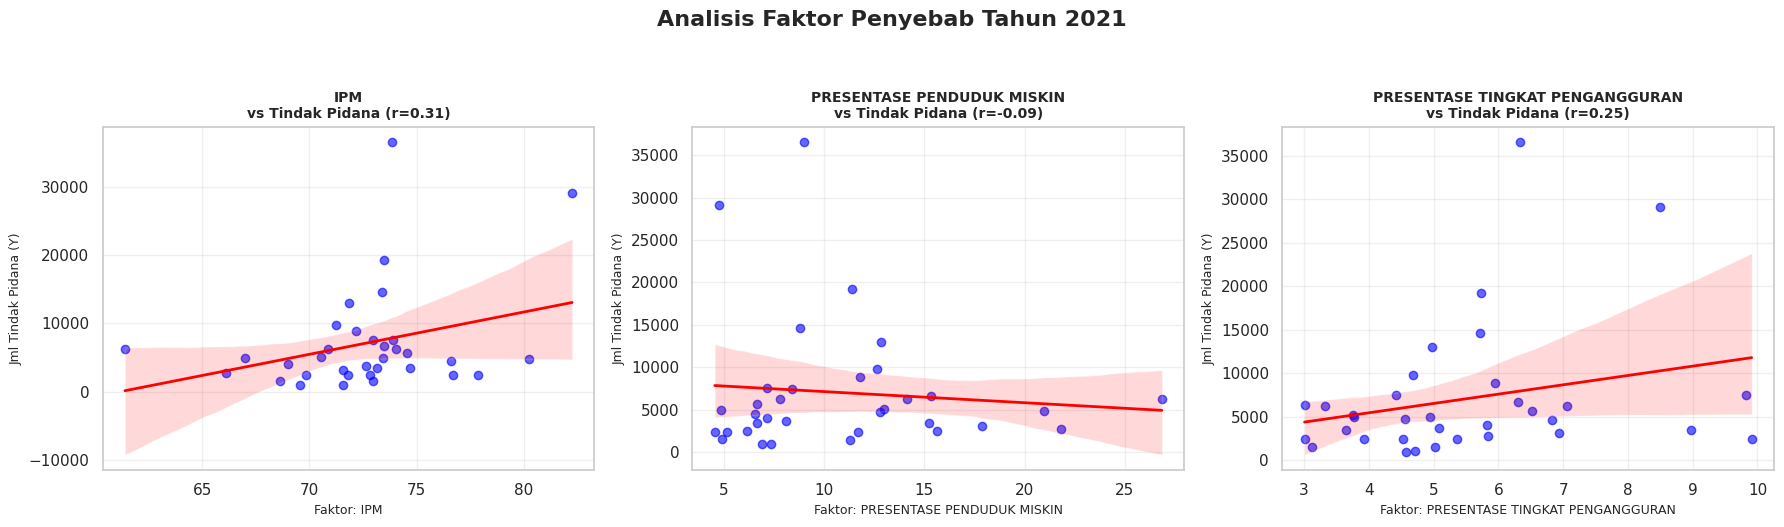

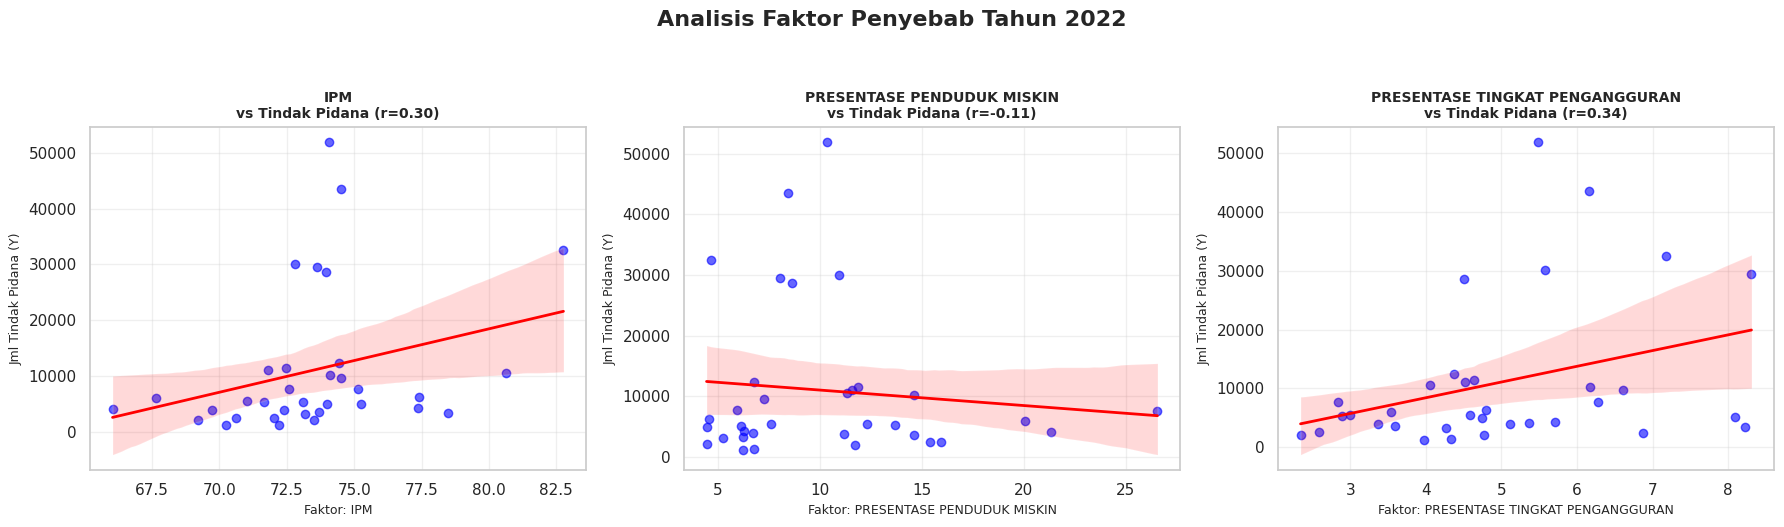

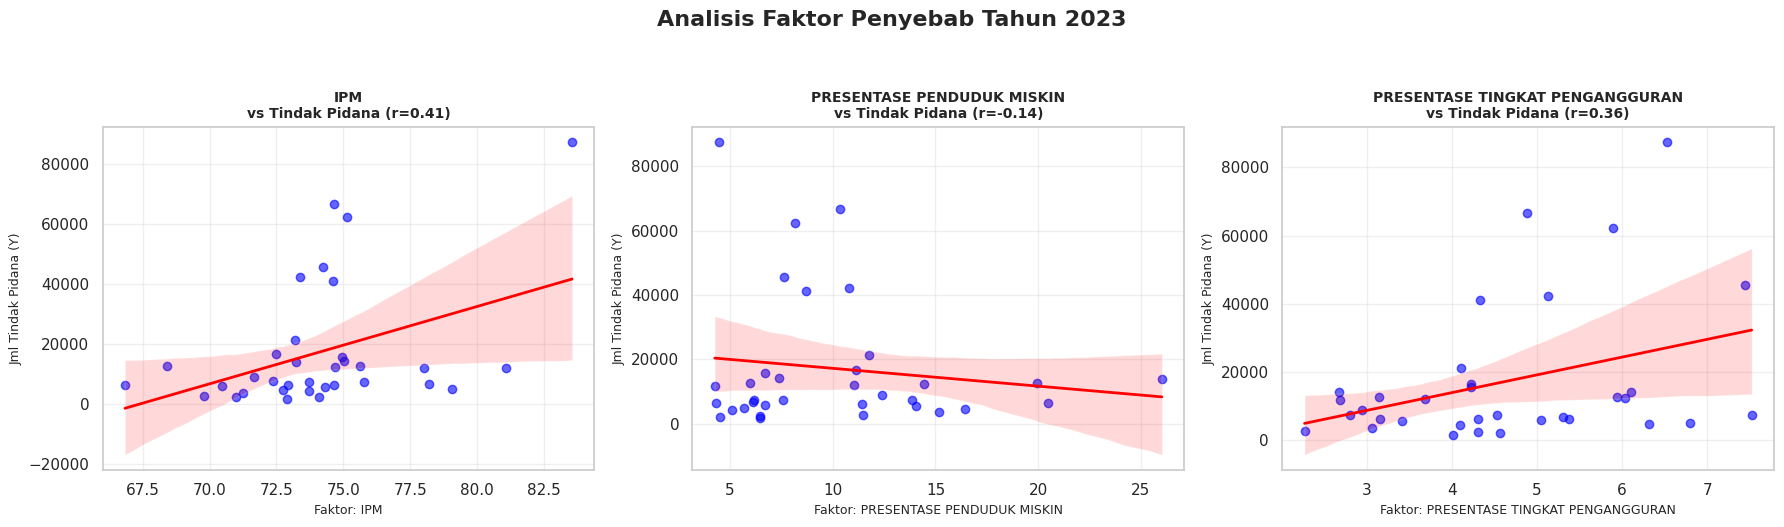


Membuat Heatmap Korelasi...


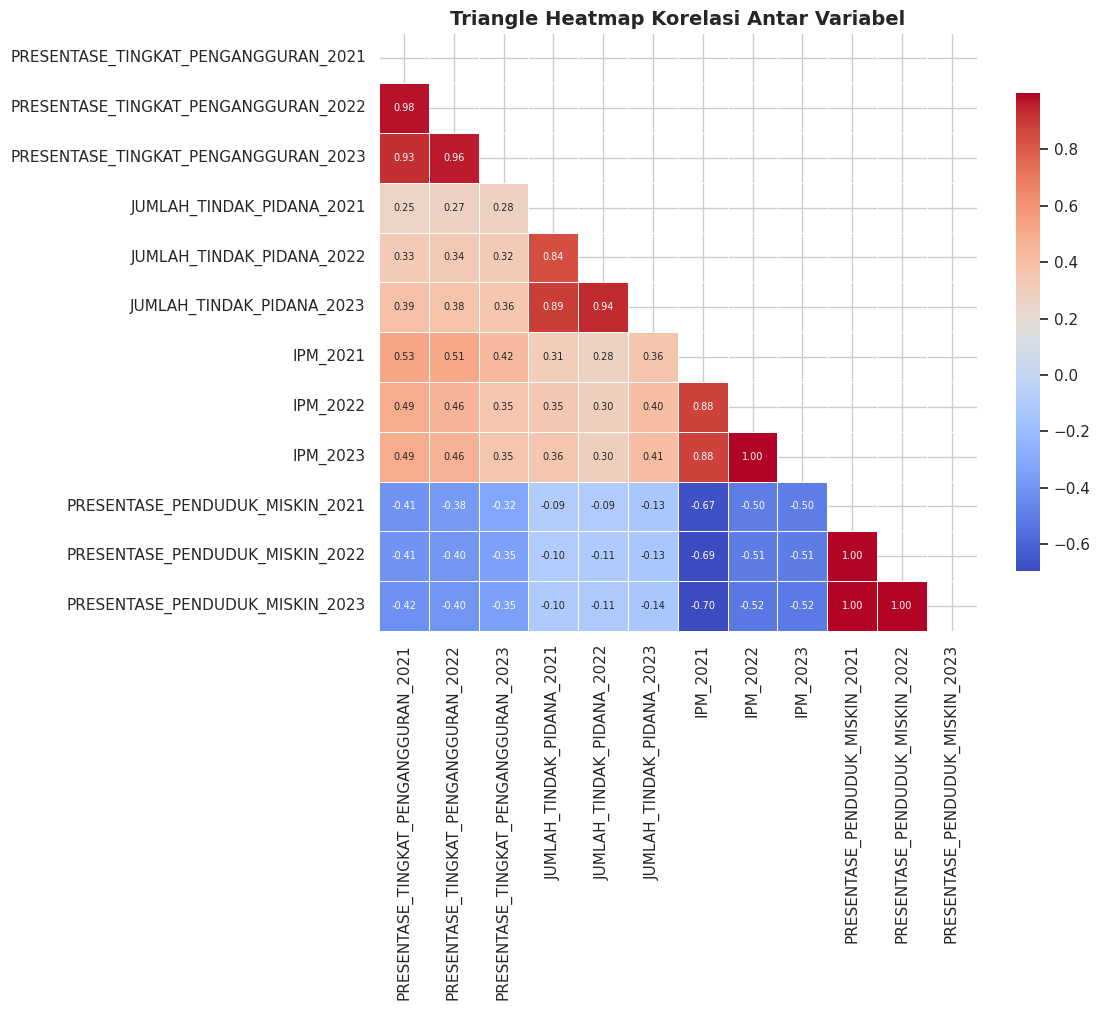

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings

# Mengabaikan warning agar output lebih bersih
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD DATA & CLEANING
try:
    df = pd.read_excel("/content/gabungan sudah fix.xlsx")
    print("File berhasil dimuat.\n")
except FileNotFoundError:
    print("File tidak ditemukan. Pastikan path file benar.")
    pass

def standar_nama_kolom(s):
    """
    Membersihkan nama kolom agar konsisten:
    JUMLAH TINDAK PIDANA 2021 -> JUMLAH_TINDAK_PIDANA_2021
    """
    s0 = str(s).strip()
    s1 = re.sub(r'\s*[-/\s]\s*(20\d{2})$', r'_\1', s0)
    m = re.search(r'(.*?)(_20\d{2})$', s1)
    if m:
        base = m.group(1).strip().replace(' ', '_')
        yr = m.group(2)
        return f"{base}{yr}"
    return s1.replace(' ', '_')

if 'df' in locals() and not df.empty:
    df.columns = [standar_nama_kolom(c) for c in df.columns]
    print("Nama Kolom Standar:", df.columns.tolist())
    cols_all = [c for c in df.columns if "_20" in c]
    base_vars = sorted(list(set([re.sub(r'_20\d{2}', '', c) for c in cols_all])))
    target_base = [v for v in base_vars if "PIDANA" in v or "KRIMINAL" in v][0] # Otomatis cari yg ada kata PIDANA
    feature_bases = [v for v in base_vars if v != target_base]

    print(f"\n[KONFIGURASI VARIABEL]")
    print(f"Variabel Dependen (Y - Akibat): {target_base}")
    print(f"Variabel Independen (X - Penyebab): {feature_bases}")

    tahun = [2021, 2022, 2023]

    #INFO DATA
    print("\n" + "="*20 + " DATA INFO " + "="*20)
    print(f"Jumlah Baris: {df.shape[0]}")
    print(f"Jumlah Kolom: {df.shape[1]}")
    print(f"\nTipe Data per Kolom:")
    print(df.dtypes)
    print(f"\nJumlah Missing Values per Kolom:")
    print(df.isnull().sum())

    print("\n5 Baris Pertama:")
    display(df.head())

    #STATISTIK DESKRIPTIF
    print("\nStatistik Deskriptif")
    display(df.describe(include="all"))


    sns.set(style="whitegrid")

    # BOXPLOT
    print("\nMembuat Boxplot (Deteksi Outliers)...")
    plt.figure(figsize=(18, 20))
    plot_num = 1
    all_vars = [target_base] + feature_bases

    for var in all_vars:
        plt.subplot(len(all_vars), 3, plot_num) # Layout Grid
        data_boxplot = []
        labels_boxplot = []
        for th in tahun:
            kol = f"{var}_{th}"
            if kol in df.columns:
                data_boxplot.append(df[kol].dropna())
                labels_boxplot.append(str(th))
        if data_boxplot:
            bp = plt.boxplot(data_boxplot, tick_labels=labels_boxplot, patch_artist=True,
                             showmeans=True, meanline=True)
            for patch in bp['boxes']:
                if var == target_base:
                    patch.set_facecolor('#ff9999')
                else:
                    patch.set_facecolor('lightblue')
            plt.title(f"Boxplot — {var.replace('_', ' ').upper()}", fontweight='bold', fontsize=10)
            plt.grid(axis='y', alpha=0.3)
            plot_num += 1
    plt.tight_layout()
    plt.show()

    #DISTRIBUTION PLOT
    print("\nMembuat Distribution Plot...")
    plt.figure(figsize=(18, 20))
    plot_num = 1
    colors = ['blue', 'green', 'red']

    for var in all_vars:
        plt.subplot(len(all_vars), 3, plot_num)
        for idx, th in enumerate(tahun):
            kol = f"{var}_{th}"
            if kol in df.columns:
                sns.histplot(df[kol].dropna(), kde=True, color=colors[idx],
                             label=f'{th}', alpha=0.4, bins=15)
        plt.title(f"Distribusi — {var.replace('_', ' ').upper()}", fontweight='bold', fontsize=10)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plot_num += 1
    plt.tight_layout()
    plt.show()

    #BAR CHART
    print("\nMembuat Bar Chart...")
    plt.figure(figsize=(16, 25))
    plot_num = 1

    for var in all_vars:
        for th in tahun:
            kol = f"{var}_{th}"
            if kol in df.columns:
                plt.subplot(len(all_vars), 3, plot_num)
                sns.barplot(
                    data=df.sort_values(kol, ascending=False),
                    x="PROVINSI", y=kol,
                    palette="viridis" if var != target_base else "magma"
                )
                plt.xticks(rotation=90, fontsize=8)
                plt.yticks(fontsize=8)
                plt.xlabel("")
                plt.title(f"{var.replace('_', ' ')}\n({th})", fontsize=9, fontweight='bold')
                plot_num += 1
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.8, wspace=0.3)
    plt.show()

    #TIME SERIES
    print("\nMembuat Time Series (Logika Normalisasi Manual 0-1)...")
    ts_norm = pd.DataFrame(index=tahun)
    for var in all_vars:
        values = []
        for th in tahun:
            kol = f"{var}_{th}"
            if kol in df.columns: values.append(df[kol].mean())
            else: values.append(None)

        valid_vals = [v for v in values if v is not None]
        if valid_vals:
            mn, mx = min(valid_vals), max(valid_vals)
            for i, th in enumerate(tahun):
                if values[i] is not None:
                    ts_norm.loc[th, var] = (values[i] - mn) / (mx - mn) if mx != mn else 0.5

    plt.figure(figsize=(14, 8))
    for var in ts_norm.columns:
        if var == target_base:
            plt.plot(ts_norm.index, ts_norm[var], marker="o", linewidth=4, markersize=10,
                     linestyle='-', color='red', label=f"[Y] {var.replace('_', ' ')}")
        else:
            plt.plot(ts_norm.index, ts_norm[var], marker="o", linewidth=2, markersize=8,
                     linestyle='--', label=f"[X] {var.replace('_', ' ')}")

    plt.title("Time Series: Perbandingan Tren Faktor (X) vs Tindak Pidana (Y)\n(Normalisasi 0-1)", fontsize=14, fontweight='bold')
    plt.xticks(tahun)
    plt.ylabel("Skala Normalisasi (0=Terendah, 1=Tertinggi)", fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    print("\nMembuat Scatter Plot: Analisis Pengaruh Faktor (X) terhadap Tindak Pidana (Y)...")
    for th in tahun:
        y_col = f"{target_base}_{th}"
        fig, axes = plt.subplots(1, len(feature_bases), figsize=(6 * len(feature_bases), 5))
        fig.suptitle(f"Analisis Faktor Penyebab Tahun {th}", fontsize=16, fontweight='bold', y=1.05)

        if y_col in df.columns:
            for i, x_base in enumerate(feature_bases):
                x_col = f"{x_base}_{th}"
                ax = axes[i] if len(feature_bases) > 1 else axes

                if x_col in df.columns:

                    sns.regplot(data=df, x=x_col, y=y_col, ax=ax,
                                scatter_kws={'alpha':0.6, 'color':'blue'},
                                line_kws={'color':'red', 'linewidth':2})


                    corr_val = df[[x_col, y_col]].corr().iloc[0, 1]

                    ax.set_title(f"{x_base.replace('_',' ')}\nvs Tindak Pidana (r={corr_val:.2f})", fontsize=10, fontweight='bold')
                    ax.set_xlabel(f"Faktor: {x_base.replace('_',' ')}", fontsize=9)
                    ax.set_ylabel("Jml Tindak Pidana (Y)", fontsize=9)
                    ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # HEATMAP
    print("\nMembuat Heatmap Korelasi...")
    plt.figure(figsize=(12, 10))
    numerik = df.select_dtypes(include=["int64", "float64"])
    corr_matrix = numerik.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm",
                linewidths=0.5, fmt='.2f', annot_kws={"size": 7},
                square=True, cbar_kws={"shrink": .8})

    plt.title("Triangle Heatmap Korelasi Antar Variabel", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("DataFrame kosong atau tidak dimuat.")